# Training Deep Neural Networks


In [1]:
import torch

In [2]:

%pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.1 MB/s eta 0:00:00


In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

# The Vanishing/Exploding Gradients Problems
- Vanishing: Los gradientes se vuelven cada vez mas pequeños mientras el algortimo progresa hacia las capas mas bajas y como resultado el gradient descent update deja a las conexiones de las capas mas ocultas casi sin cambiar haciendo que nunca converga
- Exploding: Los gradientes crecen cada vez mas hasta que las capas tienen pesos demasiado altos y el algoritmo diverge

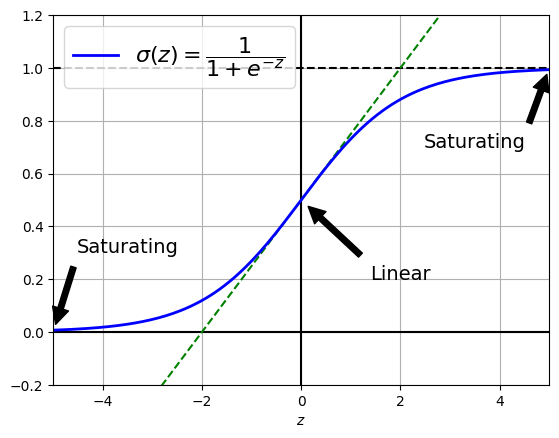

In [4]:

# extra code – this cell generates Figure 11–1
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 200)

plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [1, 1], 'k--')
plt.plot([0, 0], [-0.2, 1.2], 'k-')
plt.plot([-5, 5], [-3/4, 7/4], 'g--')
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Saturating', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Saturating', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Linear', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")
plt.grid(True)
plt.axis([-5, 5, -0.2, 1.2])
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=16)

plt.show()

# Glorot Initialization and He Initialization


necesitamos que la señal fluya bien en dos direcciones:
- hacia adelante cuando se hacen predicciones (forward)
- y en la direccion contrarea cuando se esta haciendo backpropagation a los gradientes

para que la señal fluya bien necesitamos:
- Que la diferencia de los ouputs de cada capa sea igual a la diferencia de los inputs
- y que los gradientes tengan la misma diferencia antes y despues de fluir a travez de una capa en la direccion contraria.
(actualmente es imposible garantizar las dos a menos que la capa tengan el mismo numero de inputs que de ouputs)

el modulo de Pytorch nn:linear inicializa sus pesos usando Kaiming excepto los pesos. Para solucionarlos es multiplicar los pesos por sqr(6) justo despues de crear las capas de nn.Linear para obtener la inicializacion kaiming. Tambien vamos a volver cero los biases porque no hay ningun beneficion en inicializarlos de forma random

In [5]:
import torch
import torch.nn as nn

layer=nn.Linear(40,10)
layer.weight.data *=6**0.5 #Kaiming init (or 3**0.5 for LeCun init)
torch.zero_(layer.bias.data)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

esto puede servir, pero es mejor usar una de la funciones de inicializacion que tiene disponibl el modulo torch.nn.init

In [6]:
nn.init.kaiming_uniform_(layer.weight)
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)

podemos hacer una funcion que haga eso

In [7]:
def use_he_init(module):
  if isinstance(module,nn.Linear):
    nn.init.kaiming_uniform_(module.weight)
    nn.init.zeros_(module.bias)

model=nn.Sequential(
    nn.Linear(50,40), nn.ReLU(),
    nn.Linear(40,1), nn.ReLU()
)
model.apply(use_he_init)

Sequential(
  (0): Linear(in_features=50, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=1, bias=True)
  (3): ReLU()
)

# Better Activation Functions

## Leaky ReLU

In [8]:
alpha=0.2
model=nn.Sequential(
    nn.Linear(50,40), nn.LeakyReLU(alpha)
)
nn.init.kaiming_uniform_(model[0].weight,alpha,nonlinearity="leaky_relu")

Parameter containing:
tensor([[ 0.1593,  0.2423,  0.2896,  ...,  0.2168, -0.1767,  0.2268],
        [ 0.2341, -0.0604, -0.1916,  ...,  0.1508, -0.1105,  0.2879],
        [ 0.1318, -0.0165, -0.2858,  ...,  0.3291, -0.1918,  0.1449],
        ...,
        [ 0.3233, -0.2363,  0.3036,  ..., -0.1479,  0.0499,  0.1042],
        [ 0.1543, -0.2744,  0.2458,  ..., -0.3086, -0.0208,  0.1665],
        [-0.2364,  0.1004, -0.0129,  ...,  0.0118,  0.0067,  0.0138]],
       requires_grad=True)

## ELU and SELU

# Batch Normalization

## Implementing batch norm with Pytorch
solo se añado una caoa de nn.BatchNorm1d antes y despues de cada funcion de actvacion de capa oculta y especificar el numero de inputs de cada BN laye, si añades una capa BN en la primera capa de tu modelo ya no tienes que estandarizar los inputs manualmente.

por ejemplo vamos a crear un calsificador de imagenes de Fashion MNIST usando BN en la primera capa y entonces otra vez en cada capa oculta

In [9]:
model=nn.Sequential(
    nn.Flatten(),
    nn.BatchNorm1d(1*28*28),
    nn.Linear(1*28*28,300),nn.ReLU(),
    nn.BatchNorm1d(300),
    nn.Linear(300,100),nn.ReLU(),
    nn.BatchNorm1d(100),
    nn.Linear(100,10)
)

In [10]:
dict(model[1].named_parameters()).keys()

dict_keys(['weight', 'bias'])

In [11]:
dict(model[1].named_buffers()).keys()

dict_keys(['running_mean', 'running_var', 'num_batches_tracked'])

In [12]:
model=nn.Sequential(
    nn.Flatten(),
    nn.Linear(1*28*28,300,bias=False),
    nn.BatchNorm1d(1*28*28),
    nn.ReLU(),
    nn.Linear(300,100,bias=False),
    nn.BatchNorm1d(1*28*28),
    nn.ReLU(),
    nn.Linear(100,10)
)

## Batch norm 1D,2D and 3D

# Layer Normalization
Pytorch incluye el mpdulo nn.LayerNorm. para crear una instancia debes simplemente indicar el tamaño de las dimensiones que quieres normalizar.

Por ejemplo si los inputs son batches de 100x200 RGB imagenes con forma/shape[3,100,200] y quieres normalizar cada imagen sobre cada uno de los 3 canales de color por separado, deberias usar el siguiente modulo nn.LayerNorm

In [13]:
inputs=torch.randn(32,3,100,200) #a bacth of random RGB images
layer_norm=nn.LayerNorm([100,200])
result=layer_norm(inputs) #normaliza sobre las ultimas 2 dimensiones

el siguiente codigo produce el mismo resultado

In [14]:
means=inputs.mean(dim=[2,3],keepdim=True)
vars_=inputs.var(dim=[2,3],keepdim=True,unbiased=False)
stds=torch.sqrt(vars_ + layer_norm.eps)
result=layer_norm.weight*(inputs-means)/stds+layer_norm.bias
result.shape

torch.Size([32, 3, 100, 200])

la mayoria de arquitecturas de vision por computadora que usan LN normalizan todos los canales de una. Para esto debes incluir el tamaño de la dimension del canal cuando estas creando el modulo nn.LayerNorm

In [15]:
layer_norm=nn.LayerNorm([3,100,200])
result=layer_norm(inputs) #normaliza sobre las ultimas 3 dimensiones

# Gradient Clipping
otra forma de mitigar el problema de la explosion de gradientes es clip the gradinent durante el backpropagation para que nunca exceda un limite.

ejemplo: este bucle de entrenamineto acorta la norma de cada vector gradiente a 1.0

In [16]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml

fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False)
X = torch.FloatTensor(fashion_mnist.data.reshape(-1, 1, 28, 28) / 255.)
y = torch.from_numpy(fashion_mnist.target.astype(int))
in_B = (y == 0) | (y == 2)  # Pullover or T-shirt/top
X_A, y_A = X[~in_B], y[~in_B]
y_A = torch.maximum(y_A - 2, torch.tensor(0))  # [1,3,4,5,6,7,8,9] => [0,..,7]
X_B, y_B = X[in_B], (y[in_B] == 2).to(dtype=torch.float32).view(-1, 1)

train_set_A = TensorDataset(X_A[:-7_000], y_A[:-7000])
valid_set_A = TensorDataset(X_A[-7_000:-5000], y_A[-7000:-5000])
test_set_A = TensorDataset(X_A[-5_000:], y_A[-5000:])
train_set_B = TensorDataset(X_B[:20], y_B[:20])
valid_set_B = TensorDataset(X_B[20:5000], y_B[20:5000])
test_set_B = TensorDataset(X_B[5_000:], y_B[5000:])

train_loader_A = DataLoader(train_set_A, batch_size=32, shuffle=True)
valid_loader_A = DataLoader(valid_set_A, batch_size=32)
test_loader_A = DataLoader(test_set_A, batch_size=32)
train_loader_B = DataLoader(train_set_B, batch_size=32, shuffle=True)
valid_loader_B = DataLoader(valid_set_B, batch_size=32)
test_loader_B = DataLoader(test_set_B, batch_size=32)

In [17]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            # Uncomment to activate gradient clipping:
            #nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [18]:
torch.manual_seed(42)

model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 8)
)
model_A = model_A.to(device)

In [19]:
model_A.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=8, bias=True)
)

In [20]:
n_epochs = 20
optimizer = torch.optim.SGD(model_A.parameters(), lr=0.005)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=8).to(device)
history_A = train(model_A, optimizer, xentropy, accuracy,
                  train_loader_A, valid_loader_A, n_epochs)

Epoch 1/20, train loss: 0.6363, train metric: 0.7845, valid metric: 0.8390
Epoch 2/20, train loss: 0.3525, train metric: 0.8790, valid metric: 0.8880
Epoch 3/20, train loss: 0.3054, train metric: 0.8943, valid metric: 0.8975
Epoch 4/20, train loss: 0.2811, train metric: 0.9007, valid metric: 0.8320
Epoch 5/20, train loss: 0.2652, train metric: 0.9073, valid metric: 0.8915
Epoch 6/20, train loss: 0.2519, train metric: 0.9125, valid metric: 0.8950
Epoch 7/20, train loss: 0.2397, train metric: 0.9162, valid metric: 0.8910
Epoch 8/20, train loss: 0.2317, train metric: 0.9194, valid metric: 0.9075
Epoch 9/20, train loss: 0.2234, train metric: 0.9224, valid metric: 0.9015
Epoch 10/20, train loss: 0.2149, train metric: 0.9248, valid metric: 0.9040
Epoch 11/20, train loss: 0.2098, train metric: 0.9276, valid metric: 0.9150
Epoch 12/20, train loss: 0.2029, train metric: 0.9286, valid metric: 0.8985
Epoch 13/20, train loss: 0.1982, train metric: 0.9305, valid metric: 0.9210
Epoch 14/20, train lo

# Reusing Pretrained Layers

## Transfer Learning with Pytorch

In [21]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml

fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False)
X = torch.FloatTensor(fashion_mnist.data.reshape(-1, 1, 28, 28) / 255.)
y = torch.from_numpy(fashion_mnist.target.astype(int))
in_B = (y == 0) | (y == 2)  # Pullover or T-shirt/top
X_A, y_A = X[~in_B], y[~in_B]
y_A = torch.maximum(y_A - 2, torch.tensor(0))  # [1,3,4,5,6,7,8,9] => [0,..,7]
X_B, y_B = X[in_B], (y[in_B] == 2).to(dtype=torch.float32).view(-1, 1)

train_set_A = TensorDataset(X_A[:-7_000], y_A[:-7000])
valid_set_A = TensorDataset(X_A[-7_000:-5000], y_A[-7000:-5000])
test_set_A = TensorDataset(X_A[-5_000:], y_A[-5000:])
train_set_B = TensorDataset(X_B[:20], y_B[:20])
valid_set_B = TensorDataset(X_B[20:5000], y_B[20:5000])
test_set_B = TensorDataset(X_B[5_000:], y_B[5000:])

train_loader_A = DataLoader(train_set_A, batch_size=32, shuffle=True)
valid_loader_A = DataLoader(valid_set_A, batch_size=32)
test_loader_A = DataLoader(test_set_A, batch_size=32)
train_loader_B = DataLoader(train_set_B, batch_size=32, shuffle=True)
valid_loader_B = DataLoader(valid_set_B, batch_size=32)
test_loader_B = DataLoader(test_set_B, batch_size=32)

In [22]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            # Uncomment to activate gradient clipping:
            #nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [23]:
torch.manual_seed(42)

model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 8)
)
model_A = model_A.to(device)

In [24]:
n_epochs = 20
optimizer = torch.optim.SGD(model_A.parameters(), lr=0.005)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=8).to(device)
history_A = train(model_A, optimizer, xentropy, accuracy,
                  train_loader_A, valid_loader_A, n_epochs)

Epoch 1/20, train loss: 1.7047, train metric: 0.3391, valid metric: 0.6090
Epoch 2/20, train loss: 0.6981, train metric: 0.7285, valid metric: 0.7865
Epoch 3/20, train loss: 0.4929, train metric: 0.8249, valid metric: 0.8495
Epoch 4/20, train loss: 0.3990, train metric: 0.8622, valid metric: 0.7840
Epoch 5/20, train loss: 0.3532, train metric: 0.8783, valid metric: 0.8495
Epoch 6/20, train loss: 0.3265, train metric: 0.8864, valid metric: 0.8665
Epoch 7/20, train loss: 0.3080, train metric: 0.8924, valid metric: 0.8320
Epoch 8/20, train loss: 0.2956, train metric: 0.8974, valid metric: 0.8885
Epoch 9/20, train loss: 0.2854, train metric: 0.9004, valid metric: 0.8845
Epoch 10/20, train loss: 0.2752, train metric: 0.9044, valid metric: 0.8805
Epoch 11/20, train loss: 0.2684, train metric: 0.9065, valid metric: 0.8905
Epoch 12/20, train loss: 0.2609, train metric: 0.9090, valid metric: 0.8635
Epoch 13/20, train loss: 0.2553, train metric: 0.9119, valid metric: 0.9045
Epoch 14/20, train lo

ahora podemos reusar las capas que queramos, por ejemplo, todas las capas excepto por la ouput layer

In [25]:
import copy

torch.manual_seed(42)
reused_layers=copy.deepcopy(model_A[:-1])
model_B_on_A=nn.Sequential(
    *reused_layers,
    nn.Linear(100,1)#new ouput layer for task B
    ).to(device)

para evitar errores grandes se puede congelar las capas reusadas durante las primeras epocas dandole a las nuevas capaz algo de tiempo para aprender pesos razonables

In [26]:
for layer in model_B_on_A[:-1]:
    for param in layer.parameters():
        param.requires_grad = False

In [27]:
n_epochs = 10
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B_on_A, optimizer, xentropy, accuracy,
                  train_loader_B, valid_loader_B, n_epochs)

Epoch 1/10, train loss: 0.7746, train metric: 0.5500, valid metric: 0.4653
Epoch 2/10, train loss: 0.7544, train metric: 0.5000, valid metric: 0.4590
Epoch 3/10, train loss: 0.7397, train metric: 0.5000, valid metric: 0.4602
Epoch 4/10, train loss: 0.7269, train metric: 0.5000, valid metric: 0.4633
Epoch 5/10, train loss: 0.7150, train metric: 0.5000, valid metric: 0.4703
Epoch 6/10, train loss: 0.7035, train metric: 0.5000, valid metric: 0.4831
Epoch 7/10, train loss: 0.6924, train metric: 0.5000, valid metric: 0.5046
Epoch 8/10, train loss: 0.6816, train metric: 0.5000, valid metric: 0.5261
Epoch 9/10, train loss: 0.6712, train metric: 0.5500, valid metric: 0.5494
Epoch 10/10, train loss: 0.6611, train metric: 0.6000, valid metric: 0.5715


In [28]:
for layer in model_B_on_A[2:]:
    for param in layer.parameters():
        param.requires_grad = True

In [29]:
n_epochs = 20
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B_on_A, optimizer, xentropy, accuracy,
                  train_loader_B, valid_loader_B, n_epochs)

Epoch 1/20, train loss: 0.6512, train metric: 0.6500, valid metric: 0.6016
Epoch 2/20, train loss: 0.6398, train metric: 0.6500, valid metric: 0.6345
Epoch 3/20, train loss: 0.6287, train metric: 0.6500, valid metric: 0.6655
Epoch 4/20, train loss: 0.6180, train metric: 0.7000, valid metric: 0.6954
Epoch 5/20, train loss: 0.6077, train metric: 0.7500, valid metric: 0.7245
Epoch 6/20, train loss: 0.5977, train metric: 0.8000, valid metric: 0.7516
Epoch 7/20, train loss: 0.5880, train metric: 0.9000, valid metric: 0.7697
Epoch 8/20, train loss: 0.5786, train metric: 0.9000, valid metric: 0.7898
Epoch 9/20, train loss: 0.5695, train metric: 0.9000, valid metric: 0.8066
Epoch 10/20, train loss: 0.5607, train metric: 0.9000, valid metric: 0.8201
Epoch 11/20, train loss: 0.5521, train metric: 0.9500, valid metric: 0.8307
Epoch 12/20, train loss: 0.5438, train metric: 0.9500, valid metric: 0.8400
Epoch 13/20, train loss: 0.5358, train metric: 0.9500, valid metric: 0.8488
Epoch 14/20, train lo

## Unsupervised Pretraining

# Faster Optimizers

## Momentun
Acelera el descenso de gradiente acumulando una "inercia" de los pasos anteriores, lo que evita que el modelo se estanque en mesetas y reduce las oscilaciones para llegar más rápido al mínimo global.(se puede tomar la analogia con una bola de bolos que baja por una pendiente)

Para implementarlo en Pytorch solo se usa el optimizador SGD y se pone el hiperparametro de momentun

In [30]:
optimizer=torch.optim.SGD(model.parameters(),momentum=0.9,lr=0.05)

## Nesterov Accelerated Gradient (NAG)
Es una variante del optimizador Momentun, es casi siempre mas rapido.

Para usar NAG solo se pone nesterov=True cuando se crea el optimizador SGD

In [31]:
optimizer=torch.optim.SGD(model.parameters(),momentum=0.9,nesterov=True,lr=0.05)

## AdaGrad
Adapta la tasa de aprendizaje para cada parámetro individualmente, asignando pasos más grandes a las características poco frecuentes y pasos más pequeños a las frecuentes. Esto lo hace ideal para datos dispersos, aunque su acumulación histórica de gradientes puede hacer que la tasa de aprendizaje disminuya demasiado rápido al final del entrenamiento.

## RMSProp

Este algoritmo arregla lo malo de AdaGrad acumulando solo los gradientes de las mas recientes iteraciones. Lo hacer usando exponential decay en el primer step. Normalmente se le pone al decay rate 0.9

asi se implementa en Pytorch

In [32]:
optimizer=torch.optim.RMSprop(model.parameters(),alpha=0.9,lr=0.05)

## Adam
Adaptative moment estimation, combina las ideas del optimizador momentum y RMSprop. el hiperparametro momentum decay es normalmente inicializado en 0.9 mientras que el hiperparametro de scaling daecay a menudo se inicializa en 0.999.

asi se crea un optimizador Adam en Pytorch

In [33]:
optimizer=torch.optim.Adam(model.parameters(),lr=0.05,betas=(0.9,0.999))

los siguientes 3 optimizadores son variantes de Adam

### - AdaMAx
### - NAdam
### - AdamW

In [34]:
# extra code – a little function to test an optimizer on Fashion MNIST

train_set = TensorDataset(X[:55_000], y[:55_000])
valid_set = TensorDataset(X[55_000:60_000], y[55_000:60_000])
test_set = TensorDataset(X[60_000:], y[60_000:])

def build_model(seed=42):
    torch.manual_seed(seed)
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 10)
    ).to(device)
    model.apply(use_he_init)
    return model

def test_optimizer(model, optimizer, n_epochs=10, batch_size=32):
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_set, batch_size=32)
    test_loader = DataLoader(test_set, batch_size=32)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    history = train(model, optimizer, xentropy, accuracy.to(device),
                    train_loader, valid_loader, n_epochs)
    return history, evaluate_tm(model, test_loader, accuracy)

# Learning Rate Scheduling
Deep Learning que ajusta de forma dinámica la tasa de aprendizaje (learning rate) a medida que avanza el entrenamiento del modelo

## Exponential Scheduling
La clase ExponentialLR implementa el Exponental Scheduling, donde el learning rate es multiplicado por un factor constante gamma en un intervalo, normalmente cada epoca.

Elconstructor de ExponentialLR va a esperar al menos 2 argumentos (el optimizador y el factor gamma

In [36]:
model=build_model()
optimizer=torch.optim.SGD(model.parameters(),lr=0.05)
scheduler=torch.optim.lr_scheduler.ExponentialLR(optimizer,gamma=0.9)

para usarlo debes actualizar el training loop para llamar scheduler.step() al final de cada epoca para ajustar el learning rate del optimizer

In [37]:
def train_with_scheduler(model, optimizer, loss_fn, metric, train_loader,
                         valid_loader, n_epochs, scheduler):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        losses = []
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(np.mean(losses))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_metric)
        else:
            scheduler.step()
        print(f"Learning rate: {scheduler.get_last_lr()[0]:.5f}")
    return history

def test_scheduler(model, optimizer, scheduler, n_epochs=10, batch_size=32):
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_set, batch_size=32)
    test_loader = DataLoader(test_set, batch_size=32)
    xentropy = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
    history = train_with_scheduler(
        model, optimizer, xentropy, metric, train_loader, valid_loader,
        n_epochs, scheduler)
    return history, evaluate_tm(model, test_loader, metric)

## Cosine Annealing
En vez de decrecer el learning rate de forma exponencial, se puede usar la funcion del coseno para ir del maximo learning rate(nmax) al comienzo del entrenamineto, hacia el minimo learning rate(nmin) al final. Cosine annealing trabaja mejor casi siempre

Pytorch inckuye el scheduler CosineAnnealingLR

In [38]:
cosine_scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=20,eta_min=0.001)

## Performance Scheduling
Monitorea una metrica durante el entrenamineto(normalmente validation loss) y si la matrica para de mejorar por algun tiempo, multiplica el learning rate por un factor.

Por ejemplo implementemos implementemos el scheduler basado en validation accuracy

In [39]:
#[...] se construye el modelo y opvimizador
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",patience=2,factor=0.1)

el training loop necesita ser ajustado otra vez porque debemos evaluar el metrica en cada apoca y debemos pasarle el resultado al metodo step() del scheduler.

In [ ]:
metric=torchmetrics.Accuracy(task="multiclass",num_classes=10).to(device)
for epoch in range(n_epochs):
    for X_batch,y_batch in train_loader:
      #[...] el resto del training loop permanece sin cambio
      val_metric=evaluate_tm(model,valid_loader,metric).item()
      scheduler.step(val_metric)

## Warming Up the Learning Rate
empieza con un learning rate bajito y gradualmente incrementa despues de unas epocas

## Cossine Annealing with Warm Restarts
Pytorch incluye un scheduler CosineAnnealingWarmRestarts. Debes poner T_0 el cual es el valor de Tmax del primer round de cosine annealing. Tambien debes poner T_mult en 2 si quieres duplicar Tmax en cada round(el por defecto es 1). Finalmente puedes poner eta_min(por defecto es 0)

In [41]:
cosine_repeat_scheduler=torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer,T_0=2,T_mult=2,eta_min=0.001)

# Avoiding Overfitting Through Regularization

## l1 and l2 Regularization

## Dropout

In [42]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(p=0.2), nn.Linear(28 * 28, 100), nn.ReLU(),
    nn.Dropout(p=0.2), nn.Linear(100, 100), nn.ReLU(),
    nn.Dropout(p=0.2), nn.Linear(100, 10)
).to(device)

## Monte Carlo Dropout